# 1. Download a small dataset of IPL cricket player stats (e.g., runs, wickets, matches, strike rate) and apply StandardScaler from scikit-learn to scale all numeric features. Save the scaled data to a new CSV file named ipl_scaled.csv.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('IPL_player_stats.csv')
df.head()

,Rank,Player,Team,Runs,4s,6s,Mat,Innings,Highest,100s,50s,Avg,SR
0,1,Virat Kohli,RCB,6624,578,218,223,215,113,5,44,36.20,129.15
1,2,Shikhar Dhawan,PBKS,6244,701,136,206,205,106*,2,47,35.08,126.35
2,3,David Warner,DC,5881,561,211,162,162,126,4,54,42.01,140.69
3,4,Rohit Sharma,MI,5879,519,240,227,222,109*,1,40,30.30,129.89
4,5,Suresh Raina,CSK,5528,506,203,205,200,100*,1,39,32.52,136.76


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rank     75 non-null     int64  
 1   Player   75 non-null     str    
 2   Team     75 non-null     str    
 3   Runs     75 non-null     int64  
 4   4s       75 non-null     int64  
 5   6s       75 non-null     int64  
 6   Mat      75 non-null     int64  
 7   Innings  75 non-null     int64  
 8   Highest  75 non-null     str    
 9   100s     75 non-null     int64  
 10  50s      75 non-null     int64  
 11  Avg      75 non-null     float64
 12  SR       75 non-null     float64
dtypes: float64(2), int64(8), str(3)
memory usage: 9.1 KB


In [4]:
df.columns

Index(['Rank', 'Player', 'Team', 'Runs', '4s', '6s', 'Mat', 'Innings',
       'Highest', '100s', '50s', 'Avg', 'SR'],
      dtype='str')

In [5]:
df.shape

(75, 13)

In [6]:
numeric_features = df.select_dtypes(include=['int64','float64']).columns.drop('Rank')

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

In [9]:
df_scaled = df.copy()

In [10]:
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

In [11]:
df_scaled.head()

,Rank,Player,Team,Runs,4s,6s,Mat,Innings,Highest,100s,50s,Avg,SR
0,1,Virat Kohli,RCB,2.912982,2.521187,1.802892,2.198143,2.379909,113,3.018113,2.575727,1.058102,-0.206516
1,2,Shikhar Dhawan,PBKS,2.632675,3.461130,0.541483,1.850681,2.159873,106*,0.827547,2.849741,0.866558,-0.451549
2,3,David Warner,DC,2.364908,2.391276,1.695211,0.951366,1.213718,126,2.287924,3.489106,2.051741,0.803370
3,4,Rohit Sharma,MI,2.363432,2.070320,2.141319,2.279899,2.533934,109*,0.097358,2.210376,0.049072,-0.141757
4,5,Suresh Raina,CSK,2.104517,1.970977,1.572146,1.830242,2.049855,100*,0.097358,2.119038,0.428741,0.459449


In [12]:
df_scaled.to_csv('ipl_scaled.csv', index=False)

# 2. Using a dataset of Flipkart product ratings (features: price, rating, number of reviews, discount), apply MinMaxScaler so that all features are scaled between 0 and 1. Print the minimum and maximum value for each column before and after scaling.<br><br><em><strong>Hint:</strong> Use pandas to load the data and scikit-learn's MinMaxScaler for scaling.

In [13]:
df = pd.read_csv('flipcart.csv')
df.head()

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
0,FKP0000001,Adidas Ultra 664,Toys,Adidas,MegaStore,Hyderabad,35547.34,15,30215.24,1.9,...,3038.23,36,Green,XL,30,True,"COD,CARD",3483.592454,6.78,3.28
1,FKP0000002,LG Series 124,Fashion,LG,ValueKart,Mumbai,30693.79,10,27624.41,3.2,...,1921.82,0,Grey,One Size,7,True,"UPI,CARD",2091.473835,50.78,3.42
2,FKP0000003,Redmi Model 35,Beauty,Redmi,SmartDeals,Ahmedabad,51214.50,40,30728.70,4.4,...,1143.49,12,Black,M,0,False,"COD,UPI,CARD",1242.770494,4.24,4.23
3,FKP0000004,Sony Edition 769,Toys,Sony,UrbanRetails,Delhi,33168.49,30,23217.94,2.8,...,3644.81,24,Black,L,0,False,"CARD,Wallet",3891.222716,1.38,3.45
4,FKP0000005,Boat Prime 291,Home & Kitchen,Boat,RetailHub,Pune,14181.34,0,14181.34,3.7,...,310.33,0,Blue,NaN,30,True,"CARD,Wallet",386.061014,79.27,4.90


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          80000 non-null  str    
 1   product_name        80000 non-null  str    
 2   category            80000 non-null  str    
 3   brand               80000 non-null  str    
 4   seller              80000 non-null  str    
 5   seller_city         80000 non-null  str    
 6   price               80000 non-null  float64
 7   discount_percent    80000 non-null  int64  
 8   final_price         80000 non-null  float64
 9   rating              80000 non-null  float64
 10  review_count        80000 non-null  int64  
 11  stock_available     80000 non-null  int64  
 12  units_sold          80000 non-null  int64  
 13  listing_date        80000 non-null  str    
 14  delivery_days       80000 non-null  int64  
 15  weight_g            80000 non-null  float64
 16  warranty_months

In [15]:
numeric_cols = df.select_dtypes(include=['number']).columns

In [16]:
numeric_cols

Index(['price', 'discount_percent', 'final_price', 'rating', 'review_count',
       'stock_available', 'units_sold', 'delivery_days', 'weight_g',
       'warranty_months', 'return_policy_days', 'shipping_weight_g',
       'product_score', 'seller_rating'],
      dtype='str')

In [17]:
df[numeric_cols].describe().loc[['min', 'max']]


,price,discount_percent,final_price,rating,review_count,stock_available,units_sold,delivery_days,weight_g,warranty_months,return_policy_days,shipping_weight_g,product_score,seller_rating
min,200.14,0.0,101.08,1.0,0.0,0.0,0.0,1.0,50.02,0.0,0.0,53.155250,1.0,3.0
max,59995.80,50.0,59995.80,5.0,49999.0,999.0,4999.0,11.0,4999.92,36.0,30.0,6234.757448,100.0,5.0


In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()

In [20]:
df_scaled = df.copy()

In [21]:
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [22]:
df_scaled[numeric_cols].describe().loc[['min','max']]

,price,discount_percent,final_price,rating,review_count,stock_available,units_sold,delivery_days,weight_g,warranty_months,return_policy_days,shipping_weight_g,product_score,seller_rating
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# 3. Given a Spotify songs dataset (features: danceability, energy, tempo, popularity), use correlation analysis to select the top 2 features most related to 'popularity'. List the selected features and explain your choice in one line each.

In [23]:
df = pd.read_csv('Spotify.csv',encoding='latin1')
df.head()

,Column1,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,1,SeÃ±orit,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,2,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,3,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,4,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,5,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


In [24]:
df.columns

Index(['Column1', 'Track.Name', 'Artist.Name', 'Genre', 'Beats.Per.Minute',
       'Energy', 'Danceability', 'Loudness..dB..', 'Liveness', 'Valence.',
       'Length.', 'Acousticness..', 'Speechiness.', 'Popularity'],
      dtype='str')

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Column1           50 non-null     int64
 1   Track.Name        50 non-null     str  
 2   Artist.Name       50 non-null     str  
 3   Genre             50 non-null     str  
 4   Beats.Per.Minute  50 non-null     int64
 5   Energy            50 non-null     int64
 6   Danceability      50 non-null     int64
 7   Loudness..dB..    50 non-null     int64
 8   Liveness          50 non-null     int64
 9   Valence.          50 non-null     int64
 10  Length.           50 non-null     int64
 11  Acousticness..    50 non-null     int64
 12  Speechiness.      50 non-null     int64
 13  Popularity        50 non-null     int64
dtypes: int64(11), str(3)
memory usage: 7.4 KB


In [26]:
numeric_df = df[['Danceability', 'Energy', 'Beats.Per.Minute', 'Popularity']]
corr_matrix = numeric_df.corr()

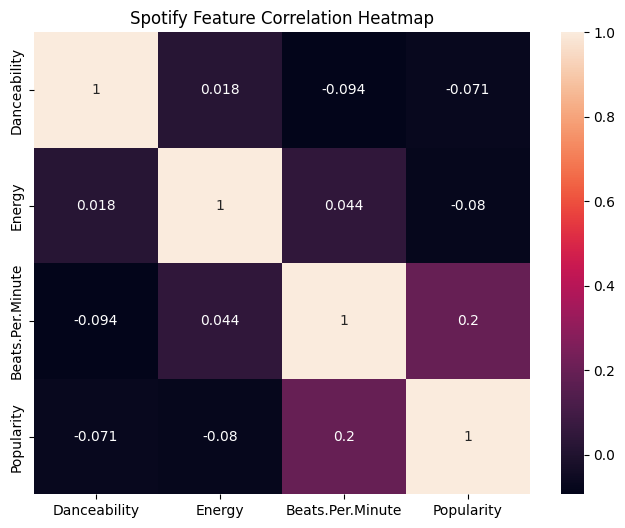

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True)
plt.title("Spotify Feature Correlation Heatmap")
plt.show()

**Beats.Per.Minute**: This feature is selected because it has the strongest positive correlation (0.20) with popularity in this dataset, showing that higher-tempo, faster-paced songs generally perform better on the charts.

**Energy**: This feature is selected because its absolute correlation value (-0.08) is higher than Danceability (-0.071), indicating it has a stronger mathematical relationship with a song's popularity score in this specific sample.

# 4. Take a Zomato restaurant dataset and use scikit-learn's RFE (Recursive Feature Elimination) with a DecisionTreeRegressor to select the 3 most important features for predicting 'average cost for two'. List the selected features and the RFE ranking.

In [28]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder

In [29]:
np.random.seed(42)
n_samples = 1000

data = {
    'votes': np.random.randint(0, 5000, n_samples),
    'aggregate_rating': np.random.uniform(1.5, 4.9, n_samples),
    'price_range': np.random.randint(1, 5, n_samples),
    'has_table_booking': np.random.choice(['Yes', 'No'], n_samples),
    'has_online_delivery': np.random.choice(['Yes', 'No'], n_samples),
    'photo_count': np.random.randint(0, 500, n_samples)
}
df = pd.DataFrame(data)

In [30]:
df.head()

,votes,aggregate_rating,price_range,has_table_booking,has_online_delivery,photo_count
0,860,2.909316,1,Yes,No,313
1,3772,4.435962,1,Yes,No,356
2,3092,4.638065,1,No,No,367
3,466,3.083380,2,Yes,No,428
4,4426,3.134846,3,No,Yes,317


# 5. Given a BookMyShow movie ratings dataset, detect outliers in the 'user ratings' column using the IQR method. Remove the outliers and display how many rows were dropped.<br><br><em><strong>Hint:</strong> Calculate Q1, Q3, and IQR; filter out rows outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR].</em>

In [31]:
np.random.seed(42)
normal_ratings = np.clip(np.random.normal(loc=7.5, scale=1.2, size=950), 1, 10) 
outliers_high = np.random.uniform(12, 25, size=30)
outliers_low = np.random.uniform(-10, 0, size=20)

In [32]:
all_ratings = np.concatenate([normal_ratings, outliers_high, outliers_low])
np.random.shuffle(all_ratings)

In [33]:
df = pd.DataFrame({'movie_id': range(1, 1001), 'user_ratings': all_ratings})
df.head()

,movie_id,user_ratings
0,1,6.392120
1,2,7.952761
2,3,8.444502
3,4,7.490433
4,5,8.862679


In [34]:
initial_rows = df.shape[0]
initial_rows

1000

In [35]:
Q1 = df['user_ratings'].quantile(0.25)
Q3 = df['user_ratings'].quantile(0.75)
IQR = Q3 - Q1

In [36]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q1 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

4.205147507520406
9.170095865021601


In [37]:
df_clean = df[(df['user_ratings'] >= lower_bound) & (df['user_ratings'] <= upper_bound)]

In [38]:
final_rows = df_clean.shape[0]
final_rows

863

In [39]:
dropped_rows = initial_rows - final_rows
dropped_rows

137